# 03 — Random Forest (pre-publish features only, v2 feature set)

Same target and same pre-publish feature set as the v2 baseline ablation in `02_baseline_linear_regression.ipynb` — `video_category_id`, `tag_count`, `title_length`, `title_has_caps_word`, `publish_hour`, `publish_dayofweek`. `video_trending_country` stays excluded: the v2 ablation showed most of its apparent predictive power was the small-market composition artifact (Malta/Luxembourg/Slovenia trending lists ~30-49% globally-viral padding), not real signal, and RMSE barely moved (+2.9%) when it was dropped.

**Goal**: test whether a non-linear model (which can capture interactions and non-linear effects a plain `LinearRegression` can't) does meaningfully better than the v2 linear baseline (RMSE 18,932,915 / R² 0.0972) on the exact same features and the exact same train/validation split.

In [1]:
import sys
sys.path.append('../src')

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from features import build_features

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

MODELS_DIR = Path('../models')
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path('../data/processed/train.parquet')
df = pd.read_parquet(DATA_PATH)
df = build_features(df)
print(f"Loaded and featurized {len(df):,} rows")

Matplotlib is building the font cache; this may take a moment.


Loaded and featurized 9,876,866 rows


## Feature set — identical to the v2 baseline

Rebuilt the same way as `02_baseline_linear_regression.ipynb`: start from the same raw column set (including `video_trending_country`) so the `dropna()` row filter is identical, then drop country before encoding — this reproduces the exact same `model_df` row set as the v2 ablation, which is what makes the train/validation split below reproducible.

**Target**: `video_view_count` (raw, untransformed, same as the baseline).

In [2]:
FEATURE_COLUMNS_RAW = [
    'video_category_id',
    'tag_count',
    'title_length',
    'title_has_caps_word',
    'publish_hour',
    'publish_dayofweek',
    'video_trending_country',
]
FEATURE_COLUMNS_RAW_V2 = [c for c in FEATURE_COLUMNS_RAW if c != 'video_trending_country']
TARGET_COLUMN = 'video_view_count'

model_df = df[FEATURE_COLUMNS_RAW + [TARGET_COLUMN]].dropna().copy()
print(f"Rows after dropping any remaining nulls in the feature/target set: {len(model_df):,} "
      f"(from {len(df):,})")

X_raw_v2 = model_df[FEATURE_COLUMNS_RAW_V2]
y = model_df[TARGET_COLUMN].astype('float64')

X_encoded = pd.get_dummies(X_raw_v2, columns=['video_category_id'], drop_first=True)
FEATURE_COLUMNS = list(X_encoded.columns)
print(f"Feature matrix shape after one-hot encoding: {X_encoded.shape}")

Rows after dropping any remaining nulls in the feature/target set: 9,876,866 (from 9,876,866)
Feature matrix shape after one-hot encoding: (9876866, 19)


## Confirm this matches the saved v2 baseline feature list

`models/baseline_feature_columns.json` was overwritten at the end of the baseline notebook to hold the v2 (no-country) column list. Loading it here and comparing against the columns just built confirms we're using the exact same 19 features, in a way that doesn't silently drift if `build_features` or the raw feature list ever changes.

In [3]:
FEATURES_PATH = MODELS_DIR / 'baseline_feature_columns.json'
with open(FEATURES_PATH) as f:
    saved_v2_columns = json.load(f)

print(f"Saved v2 baseline feature list: {len(saved_v2_columns)} columns")
print(f"Freshly built feature list:     {len(FEATURE_COLUMNS)} columns")
assert FEATURE_COLUMNS == saved_v2_columns, (
    'Feature column mismatch vs. saved v2 baseline — cannot guarantee an apples-to-apples comparison'
)
print('Confirmed: identical column set and order to the v2 baseline.')

Saved v2 baseline feature list: 19 columns
Freshly built feature list:     19 columns
Confirmed: identical column set and order to the v2 baseline.


## Train/validation split — identical to the v2 baseline

Same `model_df` (same `dropna()` row filter, same row order), same `test_size=0.2, random_state=42` — reproduces the exact same train/validation row split as the v2 baseline, so RMSE/R² are directly comparable.

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")

Train: (7901492, 19)
Val:   (1975374, 19)


## Train RandomForestRegressor

No hyperparameter tuning yet — `n_estimators=200` and a modest `max_depth=15` just to get a real number on 7.9M training rows without an open-ended training time (a benchmark run of 10 trees at this depth took ~19s with `n_jobs=-1` on this machine, so 200 trees is a few minutes, not hours). Revisit depth/estimator count/`min_samples_leaf` once we know whether the non-linear model is even worth tuning further.

In [5]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)
print('Trained.')

Python(89128) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Trained.


## Evaluate on the validation split, compare against the v2 linear baseline

In [6]:
y_pred = rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred))
r2_rf = r2_score(y_val, y_pred)

rmse_v2_baseline = 18_932_915.0
r2_v2_baseline = 0.0972

print('=== Random Forest — validation results ===')
print(f'RMSE: {rmse_rf:,.2f} views')
print(f'R^2:  {r2_rf:.4f}')
print()
print('=== Comparison: v2 Linear Regression baseline vs. Random Forest ===')
print(f'{"":24s} {"RMSE":>18s} {"R^2":>10s}')
print(f'{"v2 Linear Regression":24s} {rmse_v2_baseline:>18,.2f} {r2_v2_baseline:>10.4f}')
print(f'{"Random Forest":24s} {rmse_rf:>18,.2f} {r2_rf:>10.4f}')
print()
print(f'RMSE change: {rmse_rf - rmse_v2_baseline:+,.2f} '
      f'({(rmse_rf - rmse_v2_baseline) / rmse_v2_baseline:+.2%})')
print(f'R^2 change:  {r2_rf - r2_v2_baseline:+.4f} '
      f'({(r2_rf - r2_v2_baseline) / r2_v2_baseline:+.2%} relative)')

=== Random Forest — validation results ===
RMSE: 9,429,240.85 views
R^2:  0.7761

=== Comparison: v2 Linear Regression baseline vs. Random Forest ===
                                       RMSE        R^2
v2 Linear Regression          18,932,915.00     0.0972
Random Forest                  9,429,240.85     0.7761

RMSE change: -9,503,674.15 (-50.20%)
R^2 change:  +0.6789 (+698.43% relative)


## Feature importances

Translating the one-hot dummy column names into readable labels before plotting — `video_category_id_Pets & Animals` becomes `Category: Pets & Animals`, the five plain numeric/binary features get short human labels.

In [7]:
NUMERIC_LABELS = {
    'tag_count': 'Tag count',
    'title_length': 'Title length',
    'title_has_caps_word': 'Title has ALL-CAPS word',
    'publish_hour': 'Publish hour',
    'publish_dayofweek': 'Publish day of week',
}


def readable_label(col: str) -> str:
    if col in NUMERIC_LABELS:
        return NUMERIC_LABELS[col]
    if col.startswith('video_category_id_'):
        return f"Category: {col[len('video_category_id_'):]}"
    return col


importances = pd.Series(rf.feature_importances_, index=FEATURE_COLUMNS)
importances.index = [readable_label(c) for c in importances.index]
importances = importances.sort_values(ascending=False)

print('=== Feature importances (all 19, descending) ===')
print(importances.to_string(float_format=lambda v: f'{v:.4f}'))

=== Feature importances (all 19, descending) ===
Title length                      0.3035
Publish hour                      0.1982
Tag count                         0.1757
Publish day of week               0.0998
Category: Gaming                  0.0506
Title has ALL-CAPS word           0.0428
Category: Music                   0.0351
Category: Entertainment           0.0248
Category: People & Blogs          0.0206
Category: Howto & Style           0.0113
Category: Sports                  0.0111
Category: Comedy                  0.0085
Category: Science & Technology    0.0061
Category: Pets & Animals          0.0061
Category: Travel & Events         0.0031
Category: Film & Animation        0.0014
Category: Education               0.0007
Category: News & Politics         0.0006
Category: Nonprofits & Activism   0.0000


Saved figure to ../reports/figures/rf_feature_importance.png


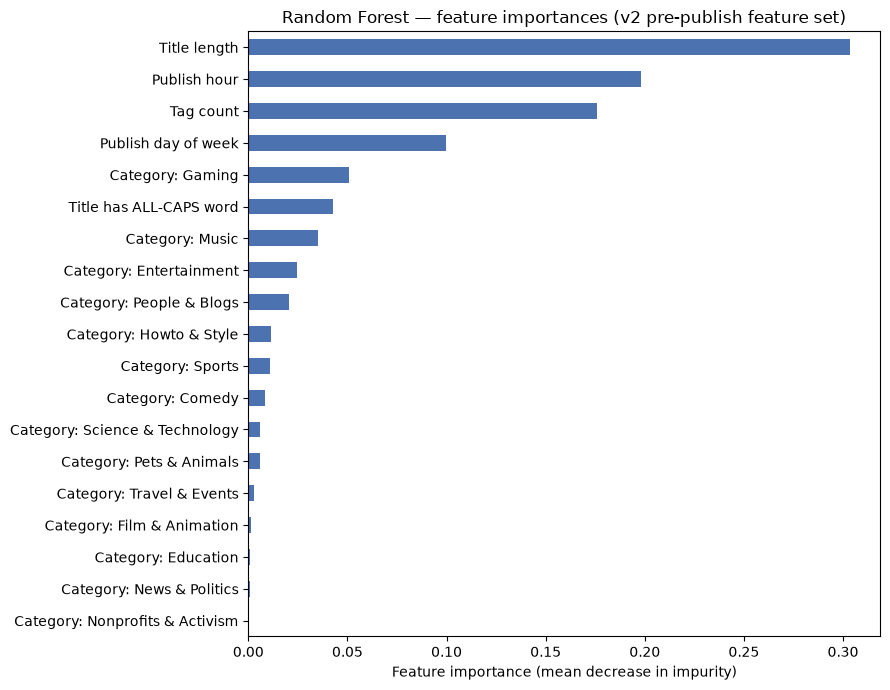

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
importances.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random Forest — feature importances (v2 pre-publish feature set)')
fig.tight_layout()

fig_path = FIGURES_DIR / 'rf_feature_importance.png'
fig.savefig(fig_path, dpi=150)
print(f'Saved figure to {fig_path}')
plt.show()

## Save the trained model

In [9]:
MODEL_PATH = MODELS_DIR / 'random_forest.pkl'
joblib.dump(rf, MODEL_PATH)
print(f'Saved model to {MODEL_PATH}')

Saved model to ../models/random_forest.pkl


## Summary (placeholder — filled in after running)